
## How the Regression Model Learns

The key idea behind regression is to find parameters (like $m$ and $b$) that minimize prediction error.



## Residuals, Loss, and Cost Function

To formalize the idea of "best fit," we need **a way to measure error**.


### Residual (Error)

The residual represents how far off our prediction is from the true value (Difference between actual and predicted values).
$$\text{error} = y - \hat{y}$$

- $y$ → actual value  
- $\hat{y}$ → predicted value  

<div align="center">

<table>
<tr>
<td align="center">
<img src="https://www.statisticsfromatoz.com/uploads/7/3/2/1/73216723/published/residuals-represent-error-jpg_1.jpg?1570130595" width="350"/>
<br>
<em>Residuals as Vertical Errors</em>
</td>

<td align="center">
<img src="https://www.statology.org/wp-content/uploads/2020/12/residuals2.png" width="350"/>
<br>
<em>Residual Distribution Around the Line</em>
</td>
</tr>
</table>

</div>

<p align="center">
<em>
Left: Residuals shown as vertical distances between actual data points and the regression line.  
Right: Residuals ideally scattered randomly around zero, indicating a good model fit. Sources: StatisticsFromAtoZ.com | Statology.org
</em>
</p>

From the above visualization, you can see that, a residual can be visualized as the **vertical distance** between:
- the actual data point  
- the regression line  

The goal of regression is to make these vertical distances as small as possible. Here:
- Positive residual → prediction is too low  
- Negative residual → prediction is too high  



### Loss Function (**per data point**)

$$Loss = (y - \hat{y})^2$$

The loss function measures how wrong a **single prediction** is.


### Cost Function (overall)

$$MSE = \frac{1}{n} \sum (y - \hat{y})^2$$

Why squared error?
- Avoid negative values  
- Penalize large errors more  
- Smooth optimization  


### Cost Function (Overall Error)

$$MSE = \frac{1}{n} \sum (y - \hat{y})^2$$

The cost function aggregates error across all data points.

- Provides a single number representing model performance  
- This is what we minimize during training  


---

### Important Distinction

- **Residual** → error for one data point  
- **Loss** → squared error for one data point  
- **Cost** → average loss across all data points  

Understanding this hierarchy is critical for grasping how regression models are trained.

---


### Error Measurement

For each data point:

$$\text{error} = y_i - \hat{y}_i$$


To combine all errors, we use **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$

Why square the error?
- Ensures all values are positive
- Penalizes larger errors more heavily



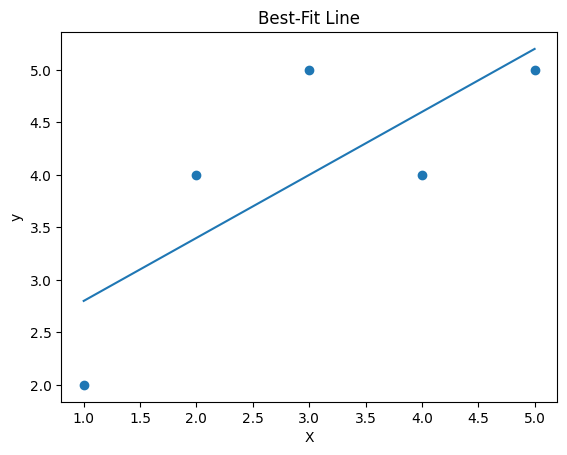

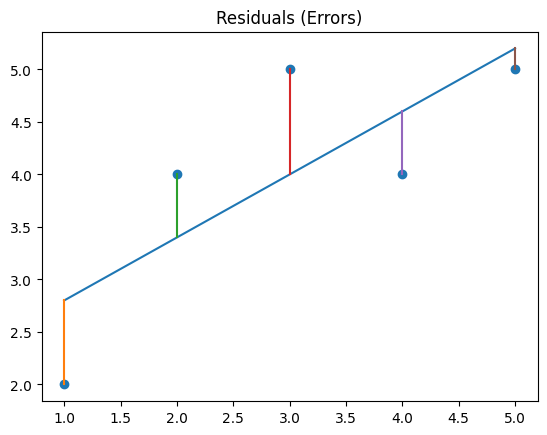

Residuals: [-0.8  0.6  1.  -0.6 -0.2]
Squared Errors: [0.64 0.36 1.   0.36 0.04]
MSE: 0.47999999999999987


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# sample data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.title("Best-Fit Line")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


'''
notice: how the line approximates data
that not all points lie on the line

'''

# Residual Visualization
plt.scatter(X, y)

# regression line
plt.plot(X, y_pred)

# draw residuals
for i in range(len(X)):
    plt.plot([X[i], X[i]], [y[i], y_pred[i]])

plt.title("Residuals (Errors)")
plt.show()

errors = y - y_pred
squared_errors = errors**2

print("Residuals:", errors)
print("Squared Errors:", squared_errors)
print("MSE:", np.mean(squared_errors))

At this stage, regression becomes more than just drawing a line.

> It becomes an **optimization problem**:

Instead of manually choosing a line, we now aim to **find the parameters of the model (e.g., slope and intercept)** that minimize the overall prediction error.

In other words, we are solving:

> Find the parameter values that **minimize the cost function**.

This shift from visualization to optimization is fundamental. It connects regression to a much broader class of machine learning algorithms, where learning is framed as minimizing a well-defined objective function.


### Optimization in Linear Regression

To minimize the cost function (typically Mean Squared Error), we use two main approaches:


The model adjusts parameters to minimize MSE using:
- Gradient Descent (iterative approach)
- Normal Equation (closed-form solution for linear regression)


#### **Gradient Descent** (Iterative Method)

- Starts with initial guesses for parameters  
- Updates parameters step-by-step  
- Moves in the direction that reduces error  
- Continues until convergence  

Key idea: Move **opposite to the gradient** to reach the minimum.


### Gradient Descent Visualization

<div align="center">
<img src="https://substackcdn.com/image/fetch/$s_!eNHI!,w_1200,h_675,c_fill,f_jpg,q_auto:good,fl_progressive:steep,g_auto/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F886ccb67-ba3b-4566-8bc9-8370b67aa060_991x475.png" width="450"/>
</div>

<p align="center">
<em>
Gradient descent iteratively updates parameters by moving in the direction of steepest decrease in the cost function.
</em>
</p>

---
## Gradient Descent: Pseudocode

The following pseudocode describes how gradient descent iteratively updates model parameters to minimize the cost function.

### General Gradient Descent Algorithm

**Input:**
- Training data $(X, y)$  
- Learning rate $\alpha$  
- Number of iterations (or convergence condition): $T$


**Initialize:**
- Set initial values for parameters (e.g., slope $m$ and intercept $b$): $m = 0$, $b = 0$



**Repeat until convergence:** (**For t = 1 to T:**)

1. Compute predictions using current parameters  
   $\hat{y} = f(X)$  

2. Compute the error (residuals)  
   $\text{error} = y - \hat{y}$  

3. Compute gradients of the cost function with respect to parameters  
   - Gradient w.r.t slope  
    $$dm = -\frac{2}{n} \sum X \cdot error$$  
   - Gradient w.r.t intercept  
   $$db = -\frac{2}{n} \sum error$$  

here: dm is gradient with respect to m and db is gradient with respect to b
4. Update parameters using the gradients  

$$m = m - α * (\text{dm})$$
$$b = b - α * (\text{db})$$


5. Optionally compute cost (MSE) to monitor progress  


**Output:**
- Final optimized parameters (m, b): return final values of $m$ and $b$


At each step:
- The gradient tells us **which direction increases error**
- We move in the **opposite direction** to reduce error

** Stopping Criteria: **

The algorithm stops when:
- Change in cost becomes very small, or  
- A fixed number of iterations is reached  

---

#### Why Optimization Matters?

This formulation allows us to:
- Systematically improve predictions  
- Scale to complex models  
- Apply the same idea across many ML algorithms  


## Learning Rate ($\alpha$)

A key component of gradient descent is the **learning rate**, usually denoted by $\alpha$.

The learning rate controls **how large each update step is** when adjusting the model parameters.


#### Why Learning Rate Matters

At each step, gradient descent updates parameters as:

> New parameter = Old parameter − $\alpha$ × (gradient)

The value of $\alpha$ determines how quickly (and how well) the model learns.



### Effects of Different Learning Rates

- **Too small ($\alpha$ is very low)**  
  - Updates are tiny  
  - Convergence is very slow  
  - Training may take many iterations  

- **Too large ($\alpha$ is very high)**  
  - Steps may overshoot the minimum  
  - The model may oscillate or diverge  
  - May never converge  

- **Well-chosen learning rate**  
  - Efficient convergence  
  - Stable updates  
  - Faster training  


<div align="center">
<img src="https://www.bdhammel.com/assets/learning-rate/lr-types.png" width="500"/>
</div>

<p align="center">
<em>
Different learning rates lead to very different behaviors: slow convergence, optimal convergence, or divergence.
</em>
</p>

#### Intuition

You can think of gradient descent like walking downhill:

- Learning rate = **step size**
- Small steps → slow but safe  
- Large steps → fast but risky  

The goal is to take steps that are **large enough to move quickly**, but **small enough to avoid missing the minimum**.

In practice, common learning rates include: 0.001, 0.01, 0.1, 0.05 etc. Often, the best value is found through experimentation or validation.


### Summary:

- Gradient tells us **which direction to move**  
- Learning rate tells us **how far to move**  

Both are essential for successfully minimizing the cost function.


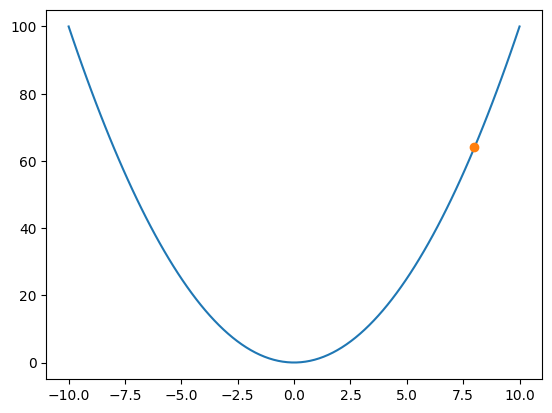

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def f(x):
    return x**2

def grad(x):
    return 2*x

x = 8
learning_rate = 0.2
points = [x]

for _ in range(15):
    x = x - learning_rate * grad(x)
    points.append(x)

fig, ax = plt.subplots()
x_vals = np.linspace(-10, 10, 100)
ax.plot(x_vals, f(x_vals))
point, = ax.plot([], [], 'o')

def update(frame):
    x = points[frame]
    point.set_data([x], [f(x)])
    return point,

ani = FuncAnimation(fig, update, frames=len(points), interval=500)

HTML(ani.to_jshtml())

# Each step updates the model parameters to reduce error, gradually moving toward the minimum of the cost function.

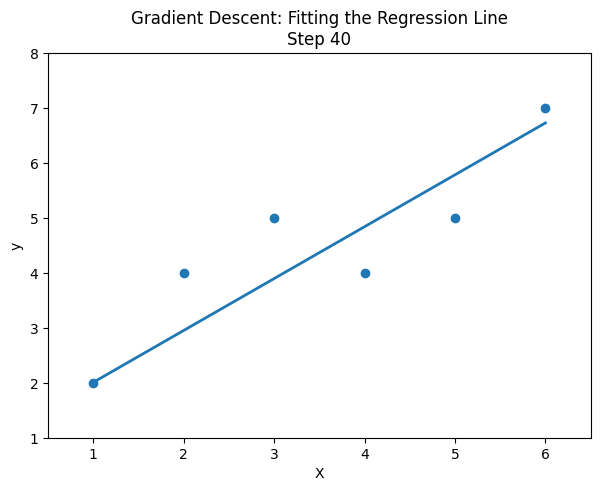

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Sample data
# -----------------------------
X = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([2, 4, 5, 4, 5, 7], dtype=float)

# -----------------------------
# Gradient Descent settings
# -----------------------------
m = 0.0   # slope
b = 0.0   # intercept
lr = 0.05
epochs = 40

m_history = [m]
b_history = [b]

n = len(X)

# Run gradient descent and store parameters
for _ in range(epochs):
    y_pred = m * X + b

    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    m = m - lr * dm
    b = b - lr * db

    m_history.append(m)
    b_history.append(b)

# -----------------------------
# Animation
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X, y)
line, = ax.plot([], [], lw=2)

ax.set_xlim(X.min() - 0.5, X.max() + 0.5)
ax.set_ylim(y.min() - 1, y.max() + 1)
ax.set_title("Gradient Descent: Fitting the Regression Line")
ax.set_xlabel("X")
ax.set_ylabel("y")

def update(frame):
    m = m_history[frame]
    b = b_history[frame]
    x_vals = np.array([X.min(), X.max()])
    y_vals = m * x_vals + b
    line.set_data(x_vals, y_vals)
    ax.set_title(f"Gradient Descent: Fitting the Regression Line\nStep {frame}")
    return line,

ani = FuncAnimation(fig, update, frames=len(m_history), interval=300, blit=True)
HTML(ani.to_jshtml())

# This animation shows how gradient descent gradually updates the slope and intercept so that the regression line better fits the data over time.

'\nThis comparison shows why the learning rate matters:\n- A very small learning rate moves slowly and takes many steps.\n- A well-chosen learning rate reaches the minimum efficiently.\n- A very large learning rate overshoots and may fail to converge.\n'

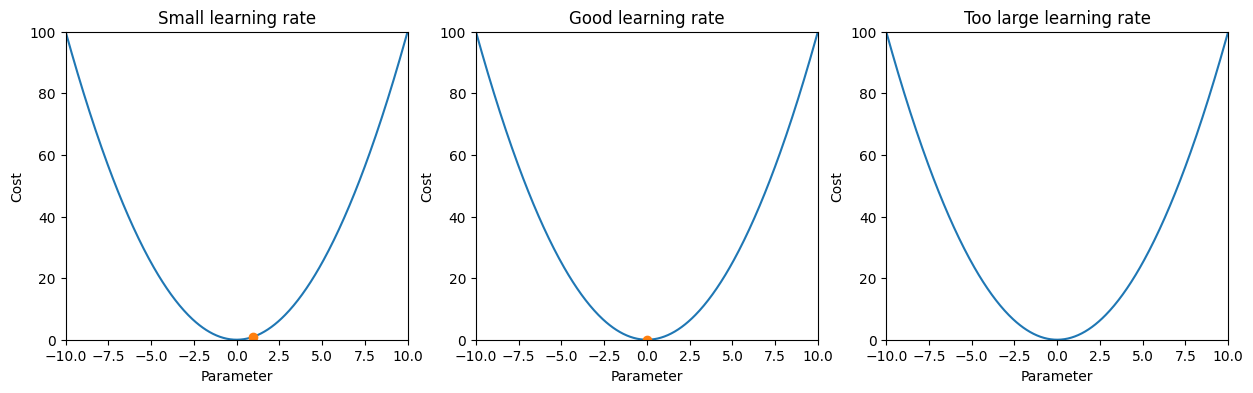

In [ ]:
# here is the learning rate comparison animation:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def cost(x):
    return x**2

def grad(x):
    return 2 * x

learning_rates = [0.05, 0.4, 1.1]
labels = ["Small learning rate", "Good learning rate", "Too large learning rate"]

steps_per_case = 20
all_points = []

for lr in learning_rates:
    x = 8.0
    points = [x]
    for _ in range(steps_per_case):
        x = x - lr * grad(x)
        points.append(x)
    all_points.append(points)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_vals = np.linspace(-10, 10, 400)

point_artists = []

for ax, label in zip(axes, labels):
    ax.plot(x_vals, cost(x_vals))
    ax.set_title(label)
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Cost")
    ax.set_xlim(-10, 10)
    ax.set_ylim(0, 100)
    point, = ax.plot([], [], 'o')
    point_artists.append(point)

def update(frame):
    artists = []
    for i, point in enumerate(point_artists):
        x = all_points[i][frame]
        point.set_data([x], [cost(x)])
        artists.append(point)
    return artists

ani = FuncAnimation(fig, update, frames=steps_per_case + 1, interval=500, blit=True)
HTML(ani.to_jshtml())


'''
This comparison shows why the learning rate matters:
- A very small learning rate moves slowly and takes many steps.
- A well-chosen learning rate reaches the minimum efficiently.
- A very large learning rate overshoots and may fail to converge.
'''

### Connecting Back to Regression

In linear regression:

- The parameters are slope ($m$) and intercept ($b$)  
- Gradient descent updates these parameters  
- Each update reduces prediction error  

This is how the model "learns" from data.